In [12]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
import os
os.listdir()

['household_power_consumption.txt', 'Time series.ipynb']

In [19]:
df = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    parse_dates={'DateTime': ['Date', 'Time']},
    infer_datetime_format=True,
    na_values='?',
    low_memory=False
)


C:\Users\admin\AppData\Local\Temp\ipykernel_17520\2231949420.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(
C:\Users\admin\AppData\Local\Temp\ipykernel_17520\2231949420.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df = pd.read_csv(
C:\Users\admin\AppData\Local\Temp\ipykernel_17520\2231949420.py:1: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [20]:
# Set the DateTime column as index
df.set_index('DateTime', inplace=True)

# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB


In [21]:
df = df.apply(pd.to_numeric, errors='coerce')

df.dropna(inplace=True)


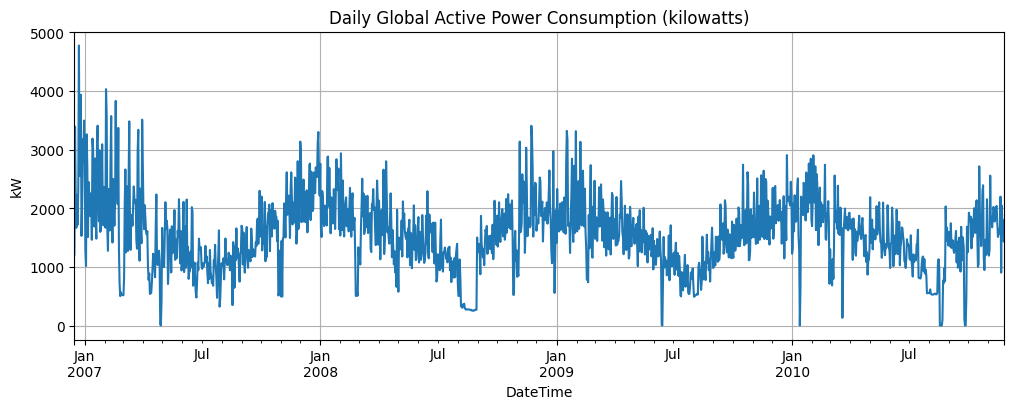

In [22]:
daily = df['Global_active_power'].resample('D').sum()

plt.figure(figsize=(12, 4))
daily.plot(title='Daily Global Active Power Consumption (kilowatts)')
plt.ylabel('kW')
plt.grid(True)
plt.show()


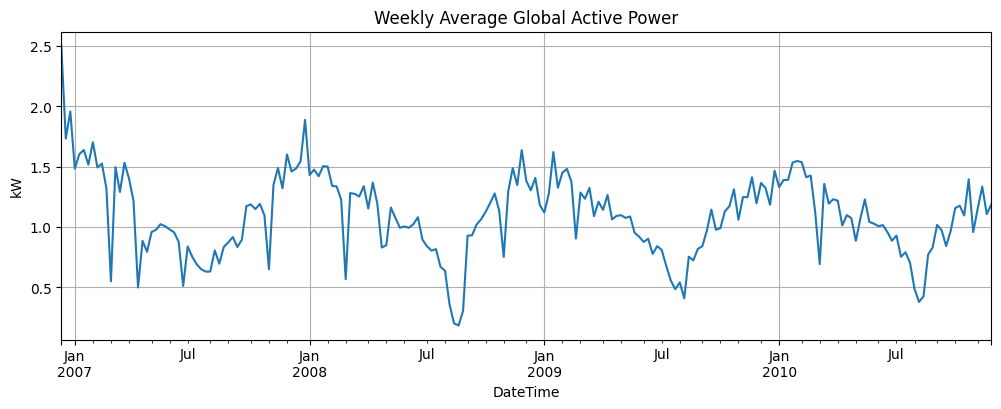

In [24]:
#Weekly Average
weekly = df['Global_active_power'].resample('W').mean()

plt.figure(figsize=(12, 4))
weekly.plot(title='Weekly Average Global Active Power')
plt.ylabel('kW')
plt.grid(True)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_17520\1657213110.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Global_active_power'].resample('M').sum()


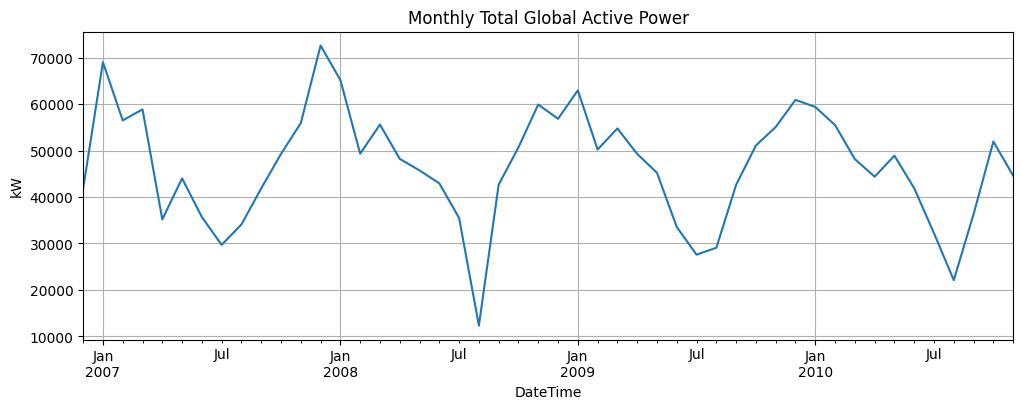

In [25]:
#Monthly Total
monthly = df['Global_active_power'].resample('M').sum()

plt.figure(figsize=(12, 4))
monthly.plot(title='Monthly Total Global Active Power')
plt.ylabel('kW')
plt.grid(True)
plt.show()


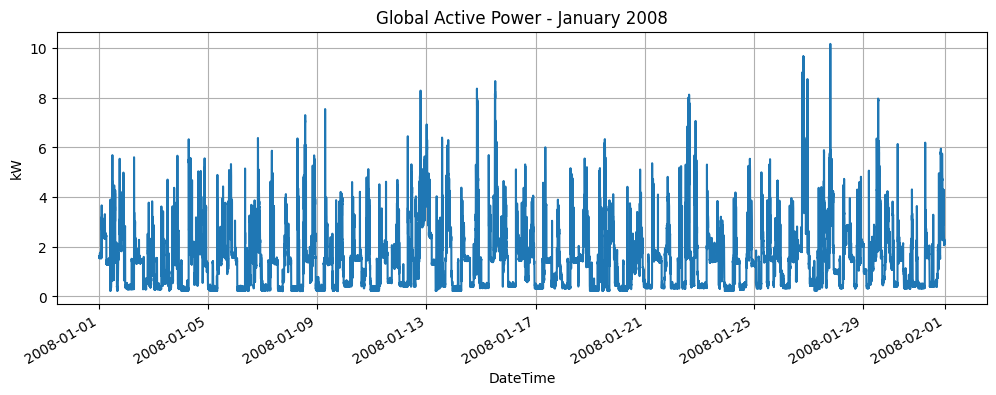

In [28]:
#Time-Based Slicing
#Example 1: January 2008
df.loc['2008-01', 'Global_active_power'].plot(figsize=(12, 4), title='Global Active Power - January 2008')
plt.ylabel('kW')
plt.grid(True)
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_17520\380692214.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.loc['2009', 'Global_active_power'].resample('M').mean().plot(figsize=(12, 4), title='Monthly Avg Power - 2009')


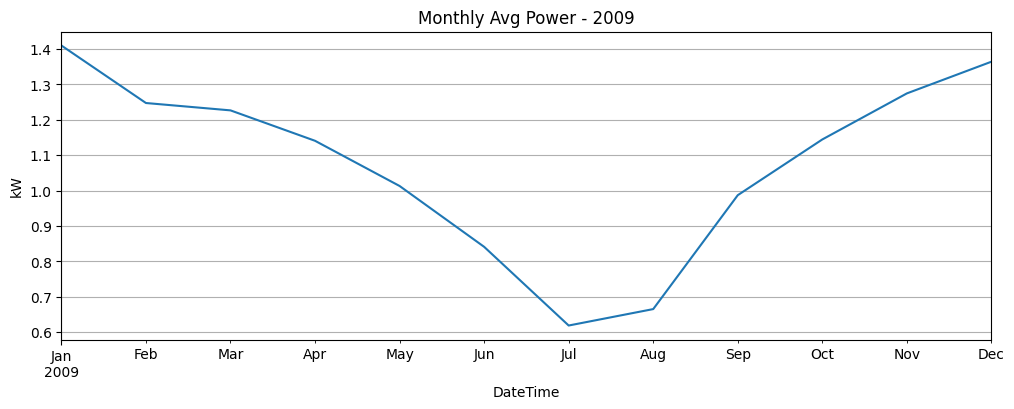

In [29]:
#Example 2: Year 2009 (monthly average)
df.loc['2009', 'Global_active_power'].resample('M').mean().plot(figsize=(12, 4), title='Monthly Avg Power - 2009')
plt.ylabel('kW')
plt.grid(True)
plt.show()
